# ScisciDB: a case study in big-ish data management using duckdb and ducklake

See [here](https://duckdb.org/docs/stable/guides/python/jupyter) for the following configs.

In [ ]:
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False 

In [2]:
import duckdb
import altair as alt
from IPython.display import Image, display

alt.renderers.enable('default')
alt.data_transformers.enable('default')

%load_ext sql
conn = duckdb.connect()
%sql conn --alias duckdb

Tip: You may define configurations in /gpfs1/home/j/s/jstonge1/scisciDB/pyproject.toml or /users/j/s/jstonge1/.jupysql/config.

Did not find user configurations in /gpfs1/home/j/s/jstonge1/scisciDB/pyproject.toml.

In [3]:
%%sql
INSTALL ducklake;
LOAD ducklake;
ATTACH 'ducklake:metadata.ducklake' AS scisciDB (DATA_PATH '/netfiles/compethicslab/scisciDB/');
USE scisciDB;

,Success


## 0. Intro

Let's first examine what just happened. We attached ourselves to a DuckLake, created in `load/load.py`. DuckLake is super interesting nice because it can potentially provide version control history for large dataset. That is, we have a set of tables called catalogs in charge of tracking everything that is happening to your database: how the schema is evolving, what has been removed or added, how we might partition the data, etc. This tracking provides us with the ability to audit any step, and, if necessary, travel back to specific versions along the way. 

_But this comes at a price_; we need to be mindful about what is happening under the hood. Catalogs are tracking any commit made to your DuckLake in the form of snapshots. If you are appending your values one by one, instead of batching, then you will create as many snapshots as there are inserted values. This, in turn, is stored in your catalogs so it will increase significantly catalog sizes. We will see how to manage that as well. We will put aside the theory and just dive right into working with catalogs and duckdb.

In [4]:
# see https://ducklake.select/manifesto/ for a description
%sql select database_name, table_name from duckdb_tables() LIMIT 10;

,database_name,table_name
0,__ducklake_metadata_scisciDB,ducklake_column
1,__ducklake_metadata_scisciDB,ducklake_column_mapping
2,__ducklake_metadata_scisciDB,ducklake_column_tag
3,__ducklake_metadata_scisciDB,ducklake_data_file
4,__ducklake_metadata_scisciDB,ducklake_delete_file
5,__ducklake_metadata_scisciDB,ducklake_files_scheduled_for_deletion
6,__ducklake_metadata_scisciDB,ducklake_file_column_stats
7,__ducklake_metadata_scisciDB,ducklake_file_partition_value
8,__ducklake_metadata_scisciDB,ducklake_inlined_data_tables
9,__ducklake_metadata_scisciDB,ducklake_metadata


Note. In the CLI, we can simply use `SHOW ALL TABLES` but for some reason Jupyter extension on VScode refuses to display it properly. Same for the profiling step later on. Now, we can use the magic of jupysql to run directly duckdb query:

In [5]:
%sql SELECT * FROM __ducklake_metadata_scisciDB.ducklake_metadata;

,key,value,scope,scope_id
0,version,0.3,None,<NA>
1,created_by,DuckDB 68d7555f68,None,<NA>
2,data_path,/gpfs1/home/j/s/jstonge1/data/scisciDB/,None,<NA>
3,encrypted,false,None,<NA>


We can inspect table metadata just from the catalog:

In [5]:
%%sql 
SELECT * 
    EXCLUDE(table_uuid, end_snapshot, table_name, path_is_relative, table_id), 
    (file_size_bytes / 1e9) as file_size_GB
FROM __ducklake_metadata_scisciDB.ducklake_table t
LEFT JOIN __ducklake_metadata_scisciDB.ducklake_table_stats s 
    ON t.table_id = s.table_id;

,begin_snapshot,schema_id,path,record_count,next_row_id,file_size_bytes,file_size_GB
0,1,0,s2_papers/,230861043,230861043,57069163374,57.069163
1,2,0,s2orc_v2/,12043581,12043581,295764756341,295.764756


We also have `abstracts` and `s2orc_v2` as VIEW, said to define a view of a query. That is, the query is run every time the view is referenced in a query, in exchange of what it doesn't take any storage.

In [7]:
%sql SELECT * FROM __ducklake_metadata_scisciDB.ducklake_view;

,view_id,view_uuid,begin_snapshot,end_snapshot,schema_id,view_name,dialect,sql,column_aliases
0,4,bf41ff5d-fc78-43db-8844-290c048c0b5d,4,<NA>,0,s2_abstracts,duckdb,SELECT * FROM read_parquet('/gpfs1/home/j/s/js...,
1,5,67a74b84-529e-45e2-a71f-b00de9e1d0f0,5,<NA>,0,s2orc_v2,duckdb,SELECT * FROM read_parquet('/gpfs1/home/j/s/js...,
2,6,f7314b31-ba37-4104-bbd5-6bebcf6df8f5,6,<NA>,0,oa_authors,duckdb,SELECT * FROM read_parquet('/gpfs1/home/j/s/js...,
3,7,2c712bfc-cdd5-4ab4-8b90-70e4ef10b94e,7,<NA>,0,oa_works,duckdb,SELECT * FROM read_parquet('/gpfs1/home/j/s/js...,


## 1. Inspect `s2_papers` and `oa_works` 

#### Q1.1: What is the timeseries of papers in semantic scholar and openalex databases?
_This is a simple question, yet without duckdb this can require some additional infrastructure. For instace, in mongoDB this would take a while to run this query without starting to dabble with indices. We could make this query faster, with hive partioning._

In [ ]:
%%sql
count_df << 
SELECT 'S2' as source, year, COUNT(*) as count
FROM scisciDB.s2_papers
WHERE year BETWEEN 1900 AND 2025
GROUP BY year

UNION ALL

SELECT 'OpenAlex' as source, publication_year as year, COUNT(*) as count
FROM scisciDB.oa_works
WHERE publication_year BETWEEN 1900 AND 2025
GROUP BY publication_year
ORDER BY year, source;

We can save duckdb output into a pandas dataframe, allowing to easily plot the result using our charting library of choice. This is super handy.

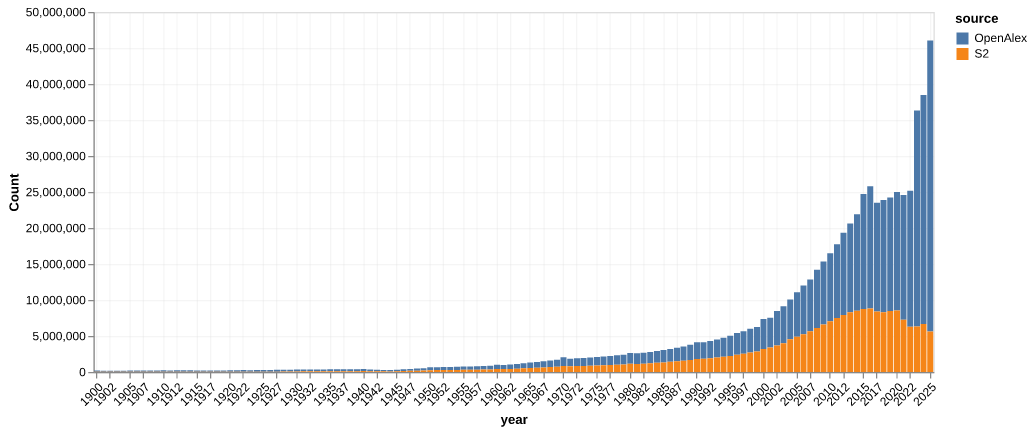

In [ ]:
alt.Chart(count_df).mark_bar().encode(
    x=alt.X('year:O', 
            axis=alt.Axis(labelAngle=-45, 
                         values=list(count_df['year'][::5]))),  # Show every 5th year
    y=alt.Y('count:Q', title='Count'),
    color="source:N",
    tooltip=['year:O', 'count:Q']
).properties(
    width=700,
    height=300
).configure_axis(
    grid=True,
    gridOpacity=0.3
).save('chart.png', scale_factor=1.2)

Image('chart.png')

This is pretty damn cool. I cannot overemphasize enough how it used to be more messy than that to do this count. I also have many more questions about both databases than I had before; what happened in 2023 so that openAlex is having that many more works while semantic scholar is leveling.

Just take a moment to realize what we just accomplished; in 10s, we analyze terabytes worth of paper data and we only have 46G of RAM on the current node. We did that thanks to duckdb, but then with the `sql` magic in jupyter notebook we could produce an interactive visualization using `altair`. This is just amazing for exploring big-ish datasets.

#### Q1.2: What is the timeseries of _parsed_ papers in semantic scholar database?

S2orc is unique in that they return a high-quality parsing of text, whenever they can:

In [11]:
%sql SELECT * FROM scisciDB.s2orc_v2 LIMIT 1;

,corpusid,openaccessinfo,title,authors,body,bibliography
0,265211158,{'disclaimer': 'This content is derived from h...,Exploring how health equity is addressed in ac...,"[Stephanie A Bultema, Kendra Piper, Esmeralda ...","{'text': ' advance equity in practice. Thus, t...",{'text': 'ACKNOWLEDGMENTSFunding for this proj...


Now, say that we want to know the proportion for which we have parsed text? The thing is that `s2_papers` don't have this field in the raw data, but we know which papers has been parsed by looking at the `s2orc_v2` table, containing the full-body parsed text. Usually, this is a simple lookup or join, where we look up `corpusid` on both tables; but here this join involves tow large tables; 270Gb and 54Gb. 

In [21]:
%%sql
CREATE OR REPLACE VIEW s2_papers_enriched AS
SELECT 
    p.*,
    EXISTS (SELECT 1 FROM scisciDB.s2orc_v2 o WHERE o.corpusid = p.corpusid) as has_fulltext
FROM scisciDB.s2_papers p
ORDER BY p.year;

,Count


#### To materialize or not to materialize, that is the question

Here it will be a bit slower that what it could be if we had altered the `s2_papers` with the `has_fulltext` column. But if we did that, our catalogs would have registered that alteration, creating a duplicated dataset as this alteration is impacting all the rows of our `s2_papers` schema. This is how we get the possibility to travel back in time with catalogs, but this come at the cost of extra storage. In this case, using a VIEW we're avoiding writing new parquets. For now, this is fine. I don't think I am gonna run this query often, but if I would, I might materialize this view into the table and accept that the tradeoff. 

In [24]:
%%sql
fulltext_df << SELECT 
    year,
    COUNT(*) as total_papers,
    COUNT(*) FILTER (WHERE has_fulltext) as papers_with_fulltext,
    FROM s2_papers_enriched 
    WHERE year > 1900
    GROUP BY year
    ORDER BY year;

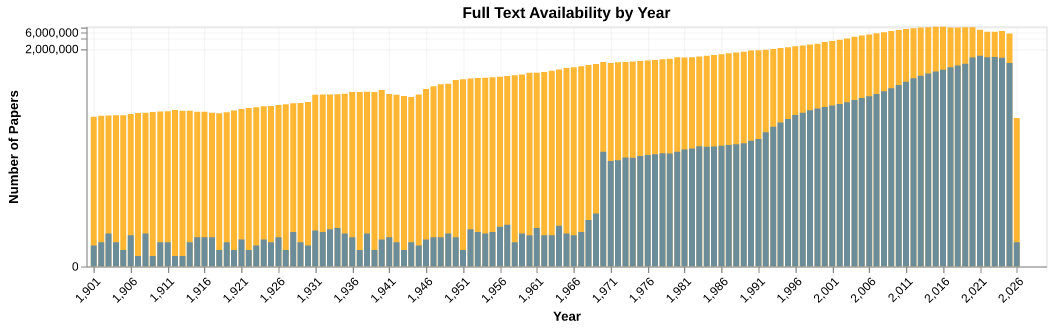

In [25]:
# Create base chart
base = alt.Chart(fulltext_df).encode(
    x=alt.X('year:Q',
            axis=alt.Axis(labelAngle=-45, values=list(fulltext_df['year'][::5])),
            title='Year')
)

# Bottom bar (total) - orange
bottom = base.mark_bar(color='orange', opacity=0.8).encode(
    y=alt.Y('total_papers:Q',
            scale=alt.Scale(type='symlog'),
            title='Number of Papers'),
    tooltip=['year', 'total_papers']
)

# Top bar (with fulltext) - blue
top = base.mark_bar(color='steelblue', opacity=0.8).encode(
    y=alt.Y('papers_with_fulltext:Q',
            scale=alt.Scale(type='symlog')),
    tooltip=['year', 'papers_with_fulltext']
)

(bottom + top).properties(
    width=800,
    height=200,
    title='Full Text Availability by Year'
).configure_axis(
    grid=True,
    gridOpacity=0.3
).save('chart.png', scale_factor=1.2)

Image('chart.png')

Analyzing performance in duckdb

In [23]:
plan_html = conn.execute("""
EXPLAIN ANALYZE
SELECT 
    year,
    COUNT(*) as total_papers,
    COUNT(*) FILTER (WHERE has_fulltext) as papers_with_fulltext,
    FROM s2_papers_enriched 
    WHERE year > 1900
    GROUP BY year
    ORDER BY year;
""").fetchall()


for row in plan_html:
    print(row[1])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────────────────────────┐
│┌───────────────────────────────────┐│
││    Query Profiling Information    ││
│└───────────────────────────────────┘│
└─────────────────────────────────────┘
 EXPLAIN ANALYZE SELECT      year,     COUNT(*) as total_papers,     COUNT(*) FILTER (WHERE has_fulltext) as papers_with_fulltext,     FROM s2_papers_enriched      WHERE year > 1900     GROUP BY year     ORDER BY year; 
┌────────────────────────────────────────────────┐
│┌──────────────────────────────────────────────┐│
││               Total Time: 4.14s              ││
│└──────────────────────────────────────────────┘│
└────────────────────────────────────────────────┘
┌───────────────────────────┐
│           QUERY           │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│      EXPLAIN_ANALYZE      │
│    ────────────────────   │
│           0 rows          │
│          (0.00s)          │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION     

## 2. Linking semantic scholar and openAlex

Both databases have their pros and cons; openAlex has better coverage on metadata about institution and people, as well as interesting topics, while semantic scholar has full citation graph and parsed text. 

_Q2.1. What if want to know the timeseries of parsed texts in S2orc for a set of topic-related papers in openAlex?_

<!-- But for today we will do our own. People don't always realize, but any JOIN is risky. Here, we will LEFT JOIN openAlex extra metadata (their topical work) onto semantic scholar, for which we have full text.

Here how we have been doing so far:
1. Create a `PaperLookup` table, where we create the JOIN. It might look like
```sql
CREATE TABLE IF NOT EXISTS papersLookup (
    corpusid INT32,             -- s2 paper id
    oa_id VARCHAR,              -- s2 paper id
    publication_year INT16,     -- s2 year id
    match_method VARCHAR,       -- DOI for now! We can add more later.
    match_confidence FLOAT,     -- 1.0. Same DOI means same papers...
    created_at TIMESTAMP
);
```
- `1.1. deduplication step`: Surprise! We have multiple DOIs in openAlex matching a single DOI in semantic scholar. We need to choose how to deduplicate that first. How do we do that? 
    - Lets create a VIEW `oa_works_deduped`.
    - By looking around, we find that some openAlex entries with same DOI have different level of information, with more information _seemingly_ being the entry that we want (lets call this feature _completeness_; see EXAMPLES...).


Current workflow

```
load/load.py -> transform/deduplicate.py -> enrich/create_lookups.py -> enrich/add_crossover_fields.py -> load/sync.py -> ...
``` -->

In [ ]:
%%sql
-- Find examples of duplicate DOIs
SELECT 
    doi,
    COUNT(*) as duplicate_count,
    ARRAY_AGG(id) as work_ids,
    ARRAY_AGG(doi_registration_agency) as agencies,
    ARRAY_AGG(concepts_count) as concept_counts
FROM scisciDB.oa_works
WHERE doi IS NOT NULL
GROUP BY doi
HAVING COUNT(*) > 1
ORDER BY duplicate_count DESC
LIMIT 10;

BinderException: Binder Error: Referenced column "concepts_count" not found in FROM clause!
Candidate bindings: "concepts", "cited_by_count", "locations_count", "countries_distinct_count", "topics"

LINE 5:     ARRAY_AGG(concepts_count) as concept_counts
                      ^

## 3. `s2orc_v2` and biobliography

Lets build a small classifier of citation intent using `s2orc_v2` and `"allenai/SciRIFF`.

In [5]:
import numpy as np
import torch
import json
import os
from pathlib import Path
from textwrap import wrap
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import accuracy_score, classification_report
import wandb

In [6]:
MODEL_CACHE_DIR = "./model_cache"
RESULTS_DIR = "./results"
OUTPUT_DIR = "./output"

Path(MODEL_CACHE_DIR).mkdir(exist_ok=True)
Path(RESULTS_DIR).mkdir(exist_ok=True)
Path(OUTPUT_DIR).mkdir(exist_ok=True)


In [7]:
os.environ["CUDA_VISIBLE_DEVICES"] = "3"  # Use GPU 3 (most free at the time, look nvidia-smi)

In [8]:
torch.cuda.is_available()

True

In [9]:
import accelerate
print(accelerate.__version__)

1.12.0


### Load Annotated dataset and raw data

In [9]:
dataset = load_dataset("allenai/SciRIFF", "4096")

In [10]:
def filter_citation_tasks(examples):
    # Keep only classification tasks that involve citations
    task_families = examples['metadata']['task_family']
    return ['classification' in tf.lower() and 'citation' in examples['input'][i].lower()
            for i, tf in enumerate(task_families)]


# Apply filter - citation classification only AND single-label only (no JSON arrays)
filtered_train = dataset['train'].filter(
    lambda x: 'classification' in x['metadata']['task_family'].lower() and
              'citation' in x['input'].lower() and
              not x['output'].strip().startswith('[')
)
filtered_val = dataset['validation'].filter(
    lambda x: 'classification' in x['metadata']['task_family'].lower() and
              'citation' in x['input'].lower() and
              not x['output'].strip().startswith('[')
)

def sample_dataset(dataset_split, sample_ratio=0.01):
    if sample_ratio >= 1.0 or len(dataset_split) == 0:
        return dataset_split

    num_samples = max(1, int(len(dataset_split) * sample_ratio))
    indices = list(range(len(dataset_split)))
    sampled_indices, _ = train_test_split(
        indices,
        train_size=num_samples,
        random_state=42
    )
    return dataset_split.select(sampled_indices)

sampled_train = sample_dataset(filtered_train, 1.0)
sampled_val = sample_dataset(filtered_val, 1.0)

In [11]:
print(sampled_train[0]['input'])

You will be presented with a citation segment from the section of an NLP research paper, as well as the context surrounding that citation. Classify the intent behind this citation by choosing from one of the following categories:
- Background: provides context or foundational information related to the topic.
- Extends: builds upon the cited work.
- Uses: applies the methods or findings of the cited work.
- Motivation: cites the work as inspiration or rationale for the research.
- CompareOrContrast: compares or contrasts the cited work with others.
- FutureWork: cites the work as a direction for future research.

Your answer should be a single word from the following list of options: ["Background", "Extends", "Uses", "Motivation", "CompareOrContrast", "FutureWork"]. Do not include any other text in your response.

Section Title:
introduction

Context before the citation:
Thus, over the past few years, along with advances in the use of learning and statistical methods for acquisition of

In [12]:
unique_labels = set()
for example in sampled_train:
    unique_labels.add(example['output'].strip())
for example in sampled_val:
    unique_labels.add(example['output'].strip())

label_list = sorted(list(unique_labels))
num_labels = len(label_list)
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

print(f"Number of citation intent labels: {num_labels}")
print(f"Labels: {label_list}")

Number of citation intent labels: 8
Labels: ['Background', 'CompareOrContrast', 'Extends', 'FutureWork', 'Method', 'Motivation', 'Result', 'Uses']


Lets now look at wrangling `s2orc_v2` into the right model format.

### Load the model

In [15]:
print("\n" + "="*60)
print("LOADING MODEL")
print("="*60)

model_name = "roberta-large"  # Larger model for better performance
print(f"Model: {model_name}")


LOADING MODEL
Model: roberta-large


In [16]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

NameError: name 'num_labels' is not defined

In [18]:
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    USE_GPU = True
else:
    print("WARNING: No GPU detected!")
    USE_GPU = False



Parameters: 355,367,944

Device: cuda
GPU: NVIDIA H200 NVL
GPU Memory: 139.81 GB


In [17]:
wandb.init(
    project="citation-intent-classification-4",
    name="roberta-large-citation-intent",
    config={
        "model_name": "roberta-large",
        "dataset": "allenai/SciRIFF",
        "task": "citation_intent_classification",
        "learning_rate": 2e-5,
    }
)

wandb: Currently logged in as: jonathanstonge7 (computational-story-lab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [18]:
# Log device info to wandb
wandb.config.update({
    "device": str(device),
    "gpu_available": USE_GPU,
    "gpu_name": torch.cuda.get_device_name(0) if USE_GPU else "N/A"
})

### Preprocessing

In [19]:
print("\n" + "="*60)
print("PREPROCESSING")
print("="*60)

max_input_length = 512

def extract_citation_context(text):
    """Extract just the citation context, removing task instructions and labels"""
    if "Section Title:" in text:
        # Extract from section title onwards (removes instructions at top)
        content = text.split("Section Title:")[1].strip()

        # Remove labels - just keep the content
        content = content.replace("Context before the citation:", " [BEFORE] ")
        content = content.replace("Citation Sentence:", " [CITATION] ")
        content = content.replace("Context after the citation:", " [AFTER] ")

        # Clean up extra whitespace
        content = " ".join(content.split())
        return content
    else:
        # Fallback: return as is
        return text

def preprocess_function(examples):
    # Remove task instructions, keep only citation context
    cleaned_inputs = [extract_citation_context(inp) for inp in examples['input']]

    # Tokenize inputs
    model_inputs = tokenizer(
        cleaned_inputs,
        max_length=max_input_length,
        truncation=True,
        padding='max_length'
    )

    # Convert text labels to numeric IDs
    model_inputs['labels'] = [label2id[output.strip()] for output in examples['output']]
    return model_inputs

print("Tokenizing training data...")
tokenized_train = sampled_train.map(preprocess_function, batched=True, remove_columns=sampled_train.column_names)
print("Tokenizing validation data...")
tokenized_val = sampled_val.map(preprocess_function, batched=True, remove_columns=sampled_val.column_names)

print("Preprocessing complete!")



PREPROCESSING
Tokenizing training data...
Tokenizing validation data...
Preprocessing complete!


### 4. TRAINING ARGUMENTS

In [20]:
print("\n" + "="*60)
print("TRAINING CONFIGURATION")
print("="*60)

if USE_GPU:
    batch_size = 8  # Reduced for roberta-large
    eval_batch_size = 16
    num_epochs = 8  # Increased from 3 to give model more time to learn minority classes
    use_fp16 = True
    logging_steps = 50
    gradient_accumulation = 2  # Effective batch size = 16
else:
    batch_size = 4
    eval_batch_size = 8
    num_epochs = 5
    use_fp16 = False
    logging_steps = 100
    gradient_accumulation = 1

# Compute class weights for handling imbalance
from sklearn.utils.class_weight import compute_class_weight

train_labels = [label2id[example['output'].strip()] for example in sampled_train]
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"Class weights computed:")
for label_id, weight in enumerate(class_weights):
    print(f"  {id2label[label_id]}: {weight:.2f}")

# Compute metrics function - optimize for macro F1 to focus on minority classes
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)
    f1_weighted = f1_score(labels, predictions, average='weighted', zero_division=0)
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

# Custom Trainer with weighted loss - use **kwargs for forward compatibility
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Use weighted cross-entropy loss
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=eval_batch_size,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    logging_steps=logging_steps,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',  # Changed from 'accuracy' to optimize for minority classes
    save_total_limit=2,
    report_to='wandb',
    fp16=use_fp16,
    gradient_accumulation_steps=gradient_accumulation,
    greater_is_better=True,  # Higher F1 macro is better
)

print(f"\nDevice: {device}")
print(f"Epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print(f"Mixed precision (FP16): {use_fp16}")
print(f"Training samples: {len(tokenized_train)}")
print(f"Optimizing for: macro F1 (focuses on minority classes)")

wandb.config.update({
    "batch_size": batch_size,
    "num_epochs": num_epochs,
    "fp16": use_fp16,
    "max_input_length": max_input_length,
    "num_labels": num_labels,
    "class_weighted_loss": True,
    "metric_for_best_model": "f1_macro"
})


TRAINING CONFIGURATION
Class weights computed:
  Background: 0.22
  CompareOrContrast: 1.72
  Extends: 8.31
  FutureWork: 8.72
  Method: 0.76
  Motivation: 6.89
  Result: 1.67
  Uses: 1.65

Device: cuda
Epochs: 8
Batch size: 8
Mixed precision (FP16): True
Training samples: 4188
Optimizing for: macro F1 (focuses on minority classes)


### 5. TRAIN

In [21]:

print("\n" + "="*60)
print("TRAINING")
print("="*60)

# Use the custom WeightedLossTrainer instead of Trainer
trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

print("Starting training with class-weighted loss...")
print("This will help the model learn minority classes better.")
train_result = trainer.train()

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)

# Save model
cached_model_path = os.path.join(MODEL_CACHE_DIR, "citation_intent_roberta")
print(f"\nSaving model to {cached_model_path}...")
model.save_pretrained(cached_model_path)
tokenizer.save_pretrained(cached_model_path)

# Save label mappings
with open(os.path.join(cached_model_path, "label_mappings.json"), 'w') as f:
    json.dump({"label2id": label2id, "id2label": id2label, "labels": label_list}, f, indent=2)
print("Model and label mappings saved successfully!")



TRAINING
Starting training with class-weighted loss...
This will help the model learn minority classes better.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.295500,1.089264,0.342718,0.474470,0.270732
2,0.791500,0.580596,0.724272,0.646176,0.730198
3,0.504600,0.608114,0.779612,0.679476,0.790840
4,0.394100,0.558382,0.834951,0.746409,0.835351
5,0.326900,0.695116,0.841748,0.748359,0.839769
6,0.149700,0.790638,0.832039,0.749853,0.832136
7,0.130000,0.913415,0.838835,0.757637,0.839373
8,0.063600,1.011400,0.842718,0.782865,0.841898



TRAINING COMPLETE!

Saving model to ./model_cache/citation_intent_roberta...
Model and label mappings saved successfully!


### 6. EVALUATION

In [22]:

print("\n" + "="*60)
print("EVALUATION")
print("="*60)

eval_results = trainer.evaluate()
print(f"Validation Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"Validation Loss: {eval_results['eval_loss']:.4f}")

# Detailed classification report
predictions = trainer.predict(tokenized_val)
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print("\nClassification Report:")
# Get unique labels present in validation set
unique_val_labels = sorted(set(true_labels.tolist() + pred_labels.tolist()))
target_names_present = [id2label[i] for i in unique_val_labels]
print(classification_report(true_labels, pred_labels, labels=unique_val_labels, target_names=target_names_present))



EVALUATION


Validation Accuracy: 0.8427
Validation Loss: 1.0114

Classification Report:
                   precision    recall  f1-score   support

       Background       0.86      0.89      0.88       597
CompareOrContrast       0.75      0.71      0.73        21
          Extends       0.50      0.50      0.50         4
       FutureWork       0.80      1.00      0.89         4
           Method       0.84      0.76      0.80       255
       Motivation       0.80      0.80      0.80         5
           Result       0.78      0.79      0.78       123
             Uses       0.86      0.90      0.88        21

         accuracy                           0.84      1030
        macro avg       0.77      0.80      0.78      1030
     weighted avg       0.84      0.84      0.84      1030



### 7. TEST ON EXAMPLES

In [24]:
print("\n" + "="*60)
print("EXAMPLE PREDICTIONS")
print("="*60)

model.to(device)
model.eval()

# Test on a few validation examples
test_examples = sampled_val.select(range(min(5, len(sampled_val))))

for idx, example in enumerate(test_examples):
    print(f"\n--- Example {idx+1} ---")
    print(f"Input: {example['input'][:300]}...")
    print(f"\nExpected label: {example['output']}")

    inputs = tokenizer(example['input'], return_tensors='pt', max_length=max_input_length, truncation=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred_id].item()

    predicted_label = id2label[pred_id]
    print(f"Predicted label: {predicted_label} (confidence: {confidence:.3f})")
    print("-" * 60)


EXAMPLE PREDICTIONS

--- Example 1 ---
Input: You will be presented with a citation segment from the section of an NLP research paper, as well as the context surrounding that citation. Classify the intent behind this citation by choosing from one of the following categories:
- Background: provides context or foundational information related to ...

Expected label: Background
Predicted label: Background (confidence: 0.986)
------------------------------------------------------------

--- Example 2 ---
Input: You will be presented with a citation segment from the section of an NLP research paper, as well as the context surrounding that citation. Classify the intent behind this citation by choosing from one of the following categories:
- Background: provides context or foundational information related to ...

Expected label: CompareOrContrast
Predicted label: Result (confidence: 0.998)
------------------------------------------------------------

--- Example 3 ---
Input: You will be pres

### SAVE model

In [25]:
results_path = os.path.join(OUTPUT_DIR, "citation_intent_results.json")
with open(results_path, 'w') as f:
    json.dump({
        'eval_accuracy': eval_results['eval_accuracy'],
        'eval_loss': eval_results['eval_loss'],
        'sample_ratio': 1.0,
        'train_samples': len(sampled_train),
        'val_samples': len(sampled_val),
        'num_labels': num_labels,
        'labels': label_list,
        'model_name': model_name
    }, f, indent=2)

print(f"\nResults saved to {results_path}")

# Finish wandb
wandb.finish()
print(f"\nWandB run completed!")

print("\n" + "="*60)
print("DONE!")
print("="*60)


Results saved to ./output/citation_intent_results.json


eval/accuracy,▁▆▇██████
eval/f1_macro,▁▅▆▇▇▇▇██
eval/f1_weighted,▁▇▇██████
eval/loss,█▁▂▁▃▄▆▇▇
eval/runtime,█▂▅▁▃▆▄▂▅
eval/samples_per_second,▁▆▄█▆▃▅▇▄
eval/steps_per_second,▁▆▄█▆▃▅▇▄
test/accuracy,▁
test/f1_macro,▁
test/f1_weighted,▁
+9,...



WandB run completed!

DONE!


### Loading back the model

In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import json

# Define paths
MODEL_CACHE_DIR = "./model_cache"
cached_model_path = f"{MODEL_CACHE_DIR}/citation_intent_roberta"

# Load the saved model and tokenizer
print("Loading model...")
model = AutoModelForSequenceClassification.from_pretrained(cached_model_path)
tokenizer = AutoTokenizer.from_pretrained(cached_model_path)

# Load label mappings
with open(f"{cached_model_path}/label_mappings.json", 'r') as f:
    label_info = json.load(f)
    label2id = label_info['label2id']
    id2label = label_info['id2label']
    id2label = {int(k): v for k, v in id2label.items()}  # Convert keys to int

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

print(f"Model loaded successfully!")
print(f"Device: {device}")
print(f"Labels: {list(label2id.keys())}")

# Helper function for predictions
def predict_citation_intent(text, max_length=512):
    """Predict citation intent for a given text."""
    inputs = tokenizer(text, return_tensors='pt', max_length=max_length, truncation=True).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred_id].item()
    
    predicted_label = id2label[pred_id]
    return predicted_label, confidence

print("\nModel ready for predictions!")

Loading model...
Model loaded successfully!
Device: cuda
Labels: ['Background', 'CompareOrContrast', 'Extends', 'FutureWork', 'Method', 'Motivation', 'Result', 'Uses']

Model ready for predictions!


In [ ]:
max_input_length = 512

In [10]:
%%sql
df << select * from scisciDB.s2orc_v2 limit 5;

In [12]:
sel_idx = 1
text = df.body[sel_idx]['text']
bib_refs = df.body[sel_idx]['annotations']['bib_ref']
paragraphs = df.body[sel_idx]['annotations']['paragraph']
section_headers = df.body[sel_idx]['annotations']['section_header']

In [23]:
df.loc[sel_idx,:]

corpusid                                                    3815239
openaccessinfo    {'disclaimer': 'This content is derived from h...
title             Partial versus early full weight bearing after...
authors           [Peng Tian, Zhi-jun Li, Gui-jun Xu, Xiao‐lei S...
body              {'text': '
Background

As society ages, the in...
bibliography      {'text': 'AcknowledgementsThis work was suppor...
Name: 1, dtype: object

In [38]:
df_paper = conn.execute("""
select * from scisciDB.s2_papers where corpusid = 3815239;
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [42]:
df_paper.url[0]

'https://www.semanticscholar.org/paper/7f7f7e7470daae93b19bf9933d5c2379e03d2a13'

In [11]:
def format_citation_for_classification(text, bib_ref, paragraphs, section_headers):
    """Format citation with context for intent classification."""
    
    ref_pos = bib_ref['start']
    
    # Find paragraph containing the citation
    para_text = ""
    para_start = 0
    para_end = len(text)
    
    for para in paragraphs:
        if para['start'] <= ref_pos < para['end']:
            para_text = text[para['start']:para['end']]
            para_start = para['start']
            para_end = para['end']
            break
    
    # Find section title (look for nearest section header before citation)
    section_title = "unknown"
    for header in section_headers:
        if header['end'] < ref_pos:
            section_title = text[header['start']:header['end']].strip()
    
    # Split paragraph into: before citation, citation sentence, after citation
    citation_sentence = para_text
    context_before = ""
    context_after = ""
    
    # Get the citation text
    citation_text = text[bib_ref['start']:bib_ref['end']]
    
    # Try to split by sentences around the citation
    rel_pos = ref_pos - para_start
    
    # Simple split: find sentence boundaries (periods followed by space/newline)
    sentences = para_text.split('. ')
    
    citation_sent_idx = 0
    char_count = 0
    for i, sent in enumerate(sentences):
        if char_count <= rel_pos < char_count + len(sent):
            citation_sent_idx = i
            break
        char_count += len(sent) + 2  # +2 for '. '
    
    citation_sentence = sentences[citation_sent_idx]
    context_before = '. '.join(sentences[:citation_sent_idx])
    context_after = '. '.join(sentences[citation_sent_idx+1:])
    
    # Format output
    output = f"""You will be presented with a citation segment from the section of an NLP research paper, as well as the context surrounding that citation. Classify the intent behind this citation by choosing from one of the following categories:
- Background: provides context or foundational information related to the topic.
- Extends: builds upon the cited work.
- Uses: applies the methods or findings of the cited work.
- Motivation: cites the work as inspiration or rationale for the research.
- CompareOrContrast: compares or contrasts the cited work with others.
- FutureWork: cites the work as a direction for future research.

Your answer should be a single word from the following list of options: ["Background", "Extends", "Uses", "Motivation", "CompareOrContrast", "FutureWork"]. Do not include any other text in your response.

Section Title:
{section_title}

Context before the citation:
{context_before}

Citation Sentence:
{citation_sentence}

Context after the citation:
{context_after}
"""
    
    return citation_sentence, output


In [ ]:
preds = []
for i,bib_ref in enumerate(bib_refs):
    citation_sentence, result = format_citation_for_classification(text, bib_ref, paragraphs, section_headers)
    
    inputs = tokenizer(result, return_tensors='pt', max_length=max_input_length, truncation=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred_id].item()

    predicted_label = id2label[pred_id]
    preds.append((citation_sentence, predicted_label, confidence))

In [35]:
for pred in set(preds):
    print(f"text: {'\n'.join(wrap(pred[0]))}")
    print(f"prediction: {pred[1]} (conf: {round(pred[2], 3)})", end="\n")
    print("---------")

text: Younger patients who underwent cemented THA have exhibited higher
revision rates due to more exercise [7]
prediction: Background (conf: 0.994)
---------
text: We estimated the heterogeneity using a standard chi-square test
(significant at P values less than 0.05 and I 2 values greater than
50%) [13]
prediction: Method (conf: 0.989)
---------
text: Some scholars believed that early FWB could increase femoral stem
subsidence and aggravate poor initial stability, leading to a high
rate of hip revision [8]
prediction: Background (conf: 0.952)
---------
text: However, one study demonstrated that during the first 3 months after
uncemented THA, the Harris scores of hip joints in the FWB group were
higher than in the PWB group [19]
prediction: Background (conf: 0.96)
---------
text: Femoral component subsidence was defined as a change of more than 4 mm
[22]
prediction: Method (conf: 0.901)
---------
text: If the femoral stem prosthesis does not achieve a full match when
placed in the fem

## 4. Reconstructing topics

In [4]:
conn.execute("show all tables").df()

,database,schema,name,column_names,column_types,temporary
0,__ducklake_metadata_scisciDB,main,ducklake_column,"[column_id, begin_snapshot, end_snapshot, tabl...","[BIGINT, BIGINT, BIGINT, BIGINT, BIGINT, VARCH...",False
1,__ducklake_metadata_scisciDB,main,ducklake_column_mapping,"[mapping_id, table_id, type]","[BIGINT, BIGINT, VARCHAR]",False
2,__ducklake_metadata_scisciDB,main,ducklake_column_tag,"[table_id, column_id, begin_snapshot, end_snap...","[BIGINT, BIGINT, BIGINT, BIGINT, VARCHAR, VARC...",False
3,__ducklake_metadata_scisciDB,main,ducklake_data_file,"[data_file_id, table_id, begin_snapshot, end_s...","[BIGINT, BIGINT, BIGINT, BIGINT, BIGINT, VARCH...",False
4,__ducklake_metadata_scisciDB,main,ducklake_delete_file,"[delete_file_id, table_id, begin_snapshot, end...","[BIGINT, BIGINT, BIGINT, BIGINT, BIGINT, VARCH...",False
5,__ducklake_metadata_scisciDB,main,ducklake_file_column_stats,"[data_file_id, table_id, column_id, column_siz...","[BIGINT, BIGINT, BIGINT, BIGINT, BIGINT, BIGIN...",False
6,__ducklake_metadata_scisciDB,main,ducklake_file_partition_value,"[data_file_id, table_id, partition_key_index, ...","[BIGINT, BIGINT, BIGINT, VARCHAR]",False
7,__ducklake_metadata_scisciDB,main,ducklake_files_scheduled_for_deletion,"[data_file_id, path, path_is_relative, schedul...","[BIGINT, VARCHAR, BOOLEAN, TIMESTAMP WITH TIME...",False
8,__ducklake_metadata_scisciDB,main,ducklake_inlined_data_tables,"[table_id, table_name, schema_version]","[BIGINT, VARCHAR, BIGINT]",False
9,__ducklake_metadata_scisciDB,main,ducklake_metadata,"[key, value, scope, scope_id]","[VARCHAR, VARCHAR, VARCHAR, BIGINT]",False
